Dataset Shape: (44898, 5)


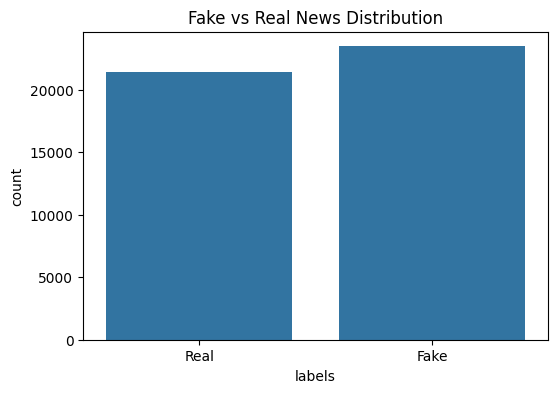

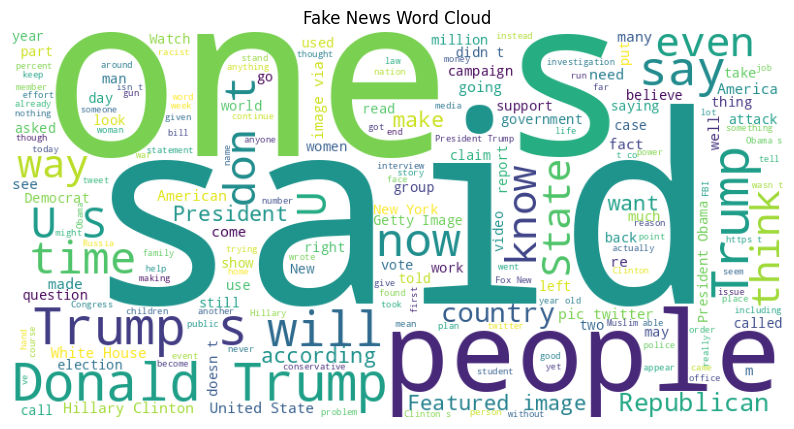

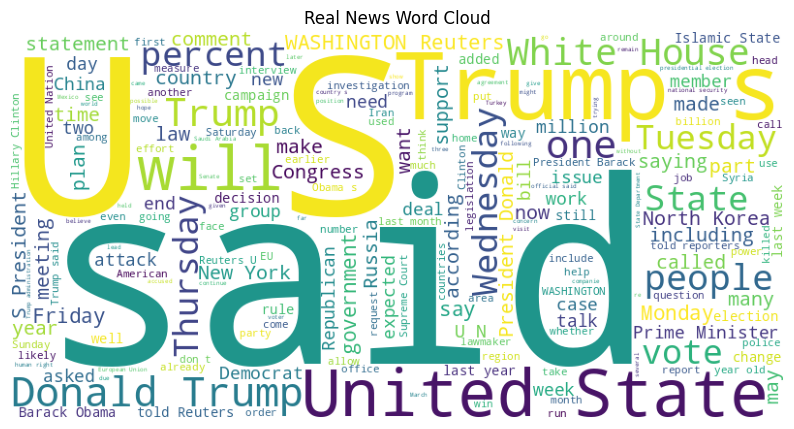

Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

Map:   0%|          | 0/8980 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `loggin

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


In [ ]:
# 1. Clear memory registry cache for torchvision if it exists from previous runs
import sys
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

# 2. Install only what we need
!pip install -q transformers datasets accelerate
!pip install -q torch
!pip install -q scikit-learn matplotlib seaborn wordcloud
!pip install -q shap lime

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
import torch

# 3. Load Data
DATA_CANDIDATES = [
    Path("/content"),
    Path.cwd(),
    Path("data"),
    Path("datasets"),
]


def find_dataset_file(filename: str):
    for base in DATA_CANDIDATES:
        candidate = base / filename
        if candidate.exists():
            return candidate
    return None


fake_path = find_dataset_file("Fake.csv")
true_path = find_dataset_file("True.csv")

if fake_path is None or true_path is None:
    raise FileNotFoundError(
        "Could not find Fake.csv and True.csv. "
        "Please place them in the current directory, ./data, ./datasets, or /content."
    )

print(f"Using Fake.csv at: {fake_path}")
print(f"Using True.csv at: {true_path}")

fake = pd.read_csv(fake_path, engine="python")
true = pd.read_csv(true_path, engine="python")

fake["labels"] = 1
true["labels"] = 0

df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")

# 4. Data Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x="labels", data=df)
plt.xticks([0, 1], ["Real", "Fake"])
plt.title("Fake vs Real News Distribution")
plt.show()

fake_text = " ".join(fake["text"].astype(str))
wordcloud_fake = WordCloud(width=800, height=400, background_color="white").generate(fake_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_fake)
plt.axis("off")
plt.title("Fake News Word Cloud")
plt.show()

real_text = " ".join(true["text"].astype(str))
wordcloud_real = WordCloud(width=800, height=400, background_color="white").generate(real_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_real)
plt.axis("off")
plt.title("Real News Word Cloud")
plt.show()

# 5. Data Preparation
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["content"] = df["title"] + " " + df["text"]

X = df["content"]
y = df["labels"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 6. Tokenization Setup
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256,
    )


train_df = pd.DataFrame({"text": X_train.values, "labels": y_train.values})
test_df = pd.DataFrame({"text": X_test.values, "labels": y_test.values})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# 7. Model & Training Setup
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)
    accuracy = accuracy_score(pred.label_ids, predictions)
    return {"accuracy": accuracy}


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 8. Train and Evaluate
trainer.train()

# Final evaluation overview
metrics = trainer.evaluate()
print("Evaluation Metrics:", metrics)